<div style="background:linear-gradient(135deg,#7a3d00 0%,#b45309 55%,#d97706 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffe9c7;font-weight:700;text-transform:uppercase">Chapter 23 · Solutions</div>
  <div style="font-size:36px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges, Worked Answers ✅</div>
  <div style="font-size:15px;color:#ffe6cc;max-width:700px;line-height:1.6">Full solutions to the five "Combining & Reshaping Data" challenges. Try them yourself first, then compare.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffe2bf">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(232)
print("pandas", pd.__version__)

pandas 3.0.3


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">CHALLENGE 1 · JOIN TWO TABLES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Inner vs left</div>
<div style="color:#4a5578;margin-top:6px">Join a products table to an orders table on product_id, once with how='inner' and once with how='left'. Report the row counts and say where NaN appears and why.</div>
</div>

In [2]:
products = pd.DataFrame({"product_id":[1,2,3], "product":["Pen","Mug","Hat"]})
orders   = pd.DataFrame({"order":[10,11,12,13], "product_id":[1,2,2,99]})
inner = orders.merge(products, on="product_id", how="inner")
left  = orders.merge(products, on="product_id", how="left")
print(f"orders: {len(orders)} | inner: {len(inner)} | left: {len(left)}")
print("\nleft join (order 13 has product_id 99, no match -> product is NaN):")
print(left)

orders: 4 | inner: 3 | left: 4

left join (order 13 has product_id 99, no match -> product is NaN):
   order  product_id product
0     10           1     Pen
1     11           2     Mug
2     12           2     Mug
3     13          99     NaN


**Answer:** The **inner** join keeps only orders whose `product_id` exists in products, so order 13 (product 99) is **dropped** (3 rows). The **left** join keeps **all 4 orders** and fills the missing `product` with **NaN** for order 13. NaN appears on the right-side columns wherever the left key has no match, which is exactly how a left join flags orphaned rows instead of silently losing them.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">CHALLENGE 2 · WIDE TO LONG</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Melt for plotting</div>
<div style="color:#4a5578;margin-top:6px">This wide table has one column per quarter. Melt it to tidy/long form so each row is one (store, quarter, sales).</div>
</div>

In [3]:
wide = pd.DataFrame({"store":["A","B"], "Q1":[10,7], "Q2":[12,9], "Q3":[15,8]})
long = wide.melt(id_vars="store", var_name="quarter", value_name="sales")
print("WIDE:"); print(wide)
print("\nLONG:"); print(long)

WIDE:
  store  Q1  Q2  Q3
0     A  10  12  15
1     B   7   9   8

LONG:
  store quarter  sales
0     A      Q1     10
1     B      Q1      7
2     A      Q2     12
3     B      Q2      9
4     A      Q3     15
5     B      Q3      8


**Answer:** `melt(id_vars="store", var_name="quarter", value_name="sales")` collapses the quarter columns into two: a **quarter** column of names and a **sales** column of values, keeping **store** as the identifier. The 2x3 wide grid becomes **6 tidy rows**, each one observation, which is the shape plotting and modeling tools expect (build on the tidy-data idea from Chapter 18).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">CHALLENGE 3 · LONG TO A GRID</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Pivot with aggregation</div>
<div style="color:#4a5578;margin-top:6px">From a long transaction log with repeated region-month pairs, build a region x month table of TOTAL amount, with row and column totals. Why pivot_table and not pivot?</div>
</div>

In [4]:
logs = pd.DataFrame({
  "region":["N","N","S","S","N"],
  "month": ["Jan","Jan","Jan","Feb","Feb"],
  "amount":[10, 5, 8, 12, 7],
})
grid = logs.pivot_table(index="region", columns="month", values="amount", aggfunc="sum", margins=True)
print(grid)

month   Feb  Jan  All
region               
N         7   15   22
S        12    8   20
All      19   23   42


**Answer:** `pivot_table(..., aggfunc="sum", margins=True)` sums the duplicate region-month entries (North/Jan has two rows, 10 and 5, which combine to 15) and `margins=True` adds the **All** totals. Plain `pivot` would raise a `ValueError` here because the region-month pairs are **not unique**; `pivot_table` is the version that aggregates, so reach for it whenever combinations can repeat.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">CHALLENGE 4 · PARSE & EXTRACT DATES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">From string to features</div>
<div style="color:#4a5578;margin-top:6px">Parse a messy signup_date column, count how many failed to parse, then extract the month name and day of week from the valid dates.</div>
</div>

In [5]:
raw = pd.Series(["2022-01-05","15/02/2022","2022/03/20","oops","2022-04-01"])
d = pd.to_datetime(raw, errors="coerce", format="mixed")
print(f"failed to parse (NaT): {d.isna().sum()}")
out = pd.DataFrame({"date":d, "month":d.dt.month_name(), "weekday":d.dt.day_name()})
print(out)

failed to parse (NaT): 1
        date     month    weekday
0 2022-01-05   January  Wednesday
1 2022-02-15  February    Tuesday
2 2022-03-20     March     Sunday
3        NaT       NaN        NaN
4 2022-04-01     April     Friday


**Answer:** `to_datetime(..., errors="coerce", format="mixed")` parses the mixed formats and turns the unparseable "oops" into **NaT** (1 failure, which you count with `.isna().sum()`, tying back to Chapters 19 and 20). From the valid datetimes the **.dt** accessor extracts features: `dt.month_name()` and `dt.day_name()`. Those extracted parts are exactly the kind of features you engineer in Chapter 24.

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">CHALLENGE 5 · CLEAN TEXT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Split and pull out a number</div>
<div style="color:#4a5578;margin-top:6px">A column holds entries like 'Order #1042 - Austin, TX'. Extract the numeric order id, and split the 'City, State' part into two columns.</div>
</div>

In [6]:
s = pd.Series(["Order #1042 - Austin, TX", "Order #88 - Reno, NV", "Order #730 - Miami, FL"])
order_id = s.str.extract(r"#(\d+)").astype(int)
place = s.str.split(" - ").str[1]            # the part after " - "
city_state = place.str.split(",", expand=True)
out = pd.DataFrame({"order_id": order_id[0],
                    "city": city_state[0].str.strip(),
                    "state": city_state[1].str.strip()})
print(out)

   order_id    city state
0      1042  Austin    TX
1        88    Reno    NV
2       730   Miami    FL


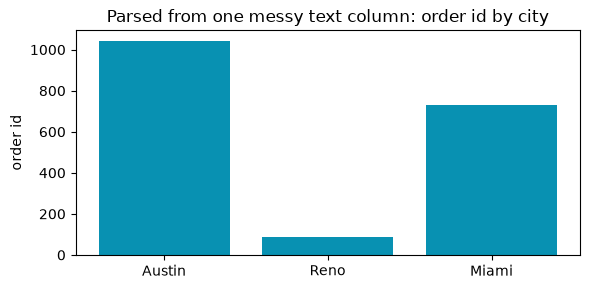

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(out["city"], out["order_id"], color="#0891b2")
ax.set(title="Parsed from one messy text column: order id by city", ylabel="order id")
plt.tight_layout(); plt.show()

**Answer:** `str.extract(r"#(\d+)")` pulls the digits after the hash into the **order_id**; `str.split(" - ").str[1]` grabs the location, and `str.split(",", expand=True)` splits it into **city** and **state** columns (remember to `.str.strip()` the pieces, the part after the comma keeps its leading space). The **.str** accessor lets you do all of this across the whole column at once, no loop required.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎉 Nicely done!</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">You joined tables the safe way, reshaped wide to long and back, parsed messy dates into features, and pulled clean fields out of text. Combining and reshaping is the plumbing that turns scattered raw files into one analysis-ready table.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>